# Code to create train and validation data splits

In [33]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from Bio import SeqIO

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

from joblib import load

from Bio.Cluster import kcluster
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.stats import pearsonr, spearmanr

import os
os.chdir("/Users/claireleblanc/Documents/grad_school/staller_lab/NN_interpretability_for_AD_prediction/Model")
from ADModel_two_state import ADModel_two_state_abund
from Data import DataReader, SplitData, FastTensorDataLoader, one_hot_encode

os.chdir("/Users/claireleblanc/Documents/grad_school/staller_lab/NN_interpretability_for_AD_prediction/Data/Faure_paper")

In [34]:
# Parameters to make figures work better with illustrator 
import matplotlib 
# For higher resoltion figures
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
plt.rcParams["font.family"] = "Helvetica" #somethings this one doesnt work
plt.rcParams['pdf.fonttype'] = 42

In [85]:
tile_data = pd.read_csv('GRB2_SH3_wrangled.csv', index_col=0)
tile_data = tile_data.sample(frac=1, random_state=6)

In [86]:
WT_seq = "TYVQALFDFDPQEDGELGFRRGDFIHVMDNSDPNWWKGACHGQTGMFPRNYVTPVN"

In [87]:
def count_diff(seq1, seq2):
    count = 0
    for aa1, aa2 in zip(seq1, seq2):
        if aa1 != aa2:
            count +=1 
    return count

In [101]:
tile_data['num_diff'] = [count_diff(seq, WT_seq) for seq in tile_data['aa_seq']]
tile_data = tile_data[tile_data['aa_seq'].str.len() == 56]
tile_data['num_diff'].value_counts()

num_diff
2    4696
1     636
0       1
Name: count, dtype: int64

In [111]:
# Train data is all single mutants + 90% of double mutants
single_tile_data = tile_data[(tile_data['num_diff'] == 1) | (tile_data['num_diff'] == 0)]
double_tile_data = tile_data[tile_data['num_diff'] == 2].iloc[:int(len(tile_data)*.9)]

In [113]:
train_data = pd.concat([single_tile_data, double_tile_data.iloc[:int(len(double_tile_data)*.9)]])
train_data

,aa_seq,abundance,activity,num_diff
1774,TYVQALFDFDPQEDGELGFRRGDCIHVMDNSDPNWWKGACHGQTGM...,0.009462,-0.021296,1
2709,TYVQALFDFDPQEDGELGFRRGDFIHVMDNSDPNWWKGACHGQTGM...,0.050971,0.083021,1
5634,TYVRALFDFDPQEDGELGFRRGDFIHVMDNSDPNWWKGACHGQTGM...,0.015263,0.002750,1
2634,TYVQALFDFDPQEDGELGFRRGDFIHVMDNSDPNWWKGACHGQTGM...,-0.318704,-0.935963,1
844,TYNQALFDFDPQEDGELGFRRGDFIHVMDNSDPNWWKGACHGQTGM...,-1.045053,-0.582507,1
...,...,...,...,...
1059,TYVLALFDFDPQEDGELGFRRGDFIHVMDNSDPNWRKGACHGQTGM...,-0.817418,-0.864645,2
5439,TYVQSLFDFVPQEDGELGFRRGDFIHVMDNSDPNWWKGACHGQTGM...,-0.964134,-0.244744,2
1127,TYVLALFDFDPQEDGELGFRRGDLIHVMDNSDPNWWKGACHGQTGM...,0.123093,-0.111761,2
1071,TYVLALFDFDPQEDGELGFRRGDFIHVMDNSDPNWWKGACHGQNGM...,-0.857077,-0.277332,2


In [114]:
val_data = double_tile_data.iloc[int(len(double_tile_data)*.9):]
val_data

,aa_seq,abundance,activity,num_diff
3679,TYVQALFDFDPQEDGELGFRRGGFIHVMDNSDPNWRKGACHGQTGM...,-0.972876,-1.163051,2
5459,TYVQTLFDFDPQEDGELGFRRGDFIHVMDNSDPNWWKGACHGQAGM...,-0.918307,-0.686348,2
3834,TYVQALFDFDPQEDGELGFRRRDFIHVMDNSDPNWWKGACHGQTGM...,-1.324310,-0.276374,2
4444,TYVQALFDFDPQEDVELGFRRGEFIHVMDNSDPNWWKGACHGQTGM...,-1.024946,-0.653989,2
3497,TYVQALFDFDPQEDGELGFRRGDFIHVVDNSDPNWWKGACHRQTGM...,-0.763951,-0.220266,2
...,...,...,...,...
380,TFVQALFDFDPQEDGELGFRRGDFIHVMDNSDPNWWKGACHGQTGT...,-0.176958,-0.075515,2
5079,TYVQALFGFDPQEDGELGFRRGDFIHVMDNSDPNWWKGACHGQTGI...,-0.998808,-0.343062,2
2226,TYVQALFDFDPQEDGELGFRRGDFIHVMDNSDPNRWKGACHGQTGV...,0.010745,-0.714708,2
232,SYVQALFDFDPQEDGELGFRRGDFIHVMDNSDPNWWKGAFHGQTGM...,-1.184600,-0.050362,2


In [115]:
test_data = double_tile_data.iloc[int(len(double_tile_data)*.9):]
test_data

,aa_seq,abundance,activity,num_diff
3679,TYVQALFDFDPQEDGELGFRRGGFIHVMDNSDPNWRKGACHGQTGM...,-0.972876,-1.163051,2
5459,TYVQTLFDFDPQEDGELGFRRGDFIHVMDNSDPNWWKGACHGQAGM...,-0.918307,-0.686348,2
3834,TYVQALFDFDPQEDGELGFRRRDFIHVMDNSDPNWWKGACHGQTGM...,-1.324310,-0.276374,2
4444,TYVQALFDFDPQEDVELGFRRGEFIHVMDNSDPNWWKGACHGQTGM...,-1.024946,-0.653989,2
3497,TYVQALFDFDPQEDGELGFRRGDFIHVVDNSDPNWWKGACHRQTGM...,-0.763951,-0.220266,2
...,...,...,...,...
380,TFVQALFDFDPQEDGELGFRRGDFIHVMDNSDPNWWKGACHGQTGT...,-0.176958,-0.075515,2
5079,TYVQALFGFDPQEDGELGFRRGDFIHVMDNSDPNWWKGACHGQTGI...,-0.998808,-0.343062,2
2226,TYVQALFDFDPQEDGELGFRRGDFIHVMDNSDPNRWKGACHGQTGV...,0.010745,-0.714708,2
232,SYVQALFDFDPQEDGELGFRRGDFIHVMDNSDPNWWKGAFHGQTGM...,-1.184600,-0.050362,2


In [116]:
val_data['aa_seq'].str.len().value_counts()

aa_seq
56    470
Name: count, dtype: int64

In [117]:
val_data[val_data['aa_seq'].str.len() == 57]['aa_seq'].values

array([], dtype=object)

In [118]:
# These are the data files used in trainning
val_data.to_csv("Faure_data_wrangled_validation.csv",index=False)
train_data.to_csv("Faure_data_wrangled_training.csv",index=False)
test_data.to_csv("Faure_data_wrangled_test.csv",index=False)

# PSD95-PDZ3

In [119]:
tile_data = pd.read_csv('PSD95_PDZ3_wrangled.csv', index_col=0)
tile_data = tile_data.sample(frac=1, random_state=6)

In [120]:
WT_seq = 'PRRIVIHRGSTGLGFNIVGGEDGEGIFISFILAGGPADLSGELRKGDQILSVNGVDLRNASHEQAAIALKNAGQTVTIIAQYKP'

In [121]:
tile_data['num_diff'] = [count_diff(seq, WT_seq) for seq in tile_data['aa_seq']]
tile_data = tile_data[tile_data['aa_seq'].str.len() == 84]
tile_data['num_diff'].value_counts()

num_diff
2    4304
1    1223
0       1
Name: count, dtype: int64

In [122]:
# Train data is all single mutants + 90% of double mutants
single_tile_data = tile_data[(tile_data['num_diff'] == 1) | (tile_data['num_diff'] == 0)]
double_tile_data = tile_data[tile_data['num_diff'] == 2].iloc[:int(len(tile_data)*.9)]

In [123]:
train_data = pd.concat([single_tile_data, double_tile_data.iloc[:int(len(double_tile_data)*.9)]])
train_data

,aa_seq,abundance,activity,num_diff
3114,PRRIVIHRGSTGLGFNIVGGEDGEGIFISFILAGGPADLSGELRKG...,-0.153422,0.074066,1
3906,PRRIVIHRGSTGLGFNIVGGEDGEGIFISFILAGGPADLSGEWRKG...,-1.095583,-1.185318,1
3090,PRRIVIHRGSTGLGFNIVGGEDGEGIFISFILAGGPADLSGELRKG...,-0.125323,-0.293011,1
2938,PRRIVIHRGSTGLGFNIVGGEDGEGIFISFILAGGPADLSGELRKG...,-0.752394,-0.605201,1
2808,PRRIVIHRGSTGLGFNIVGGEDGEGIFISFILAGGPADLRGELRKG...,-0.142992,-0.396134,1
...,...,...,...,...
4922,PRRIVIHRGSTGLVFNIVGGEDGERIFISFILAGGPADLSGELRKG...,-0.884324,-1.034073,2
4355,PRRIVIHRGSTGLGFTIVGGEDGEGIFISFILAGGPADLSGELRKG...,-0.188990,-0.071967,2
2109,PRRIVIHRGITGLGFNIVGGGDGEGIFISFILAGGPADLSGELRKG...,-0.071882,-0.318553,2
220,GRRIVIHRGSTGLGFNIVGGEDGEGIFISFILAGGPADLSGELRKG...,-0.254220,-0.111171,2


In [124]:
val_data = double_tile_data.iloc[int(len(double_tile_data)*.9):]
val_data

,aa_seq,abundance,activity,num_diff
312,GRRIVIHRGSTGLGFNIVGGEDGEGIFISFILAGGPADLSGELRKG...,-0.980819,-0.968433,2
365,GRRIVIHRGSTGLGFNIVGGEDGEGIFISFILAGGPADLSGELRKG...,-0.116596,-0.558374,2
4923,PRRIVIHRGSTGLVFNIVGGEDGGGIFISFILAGGPADLSGELRKG...,-1.221984,-1.071698,2
5074,PRRIVIHRGSTGRGFNIVGGEDGEGIFISFILAGGPADLSGELRKG...,-0.760082,-1.144672,2
1884,PRRIVIHRGITGLGFNIVGGEDGEGIFISFILAGGPADLSGELRKG...,-0.507277,-0.565572,2
...,...,...,...,...
866,PRRIRIHRGSTGLGFNIVGGEDGEGIFISFILAGGPADLSGELRKG...,-0.040312,-0.044866,2
346,GRRIVIHRGSTGLGFNIVGGEDGEGIFISFILAGGPADLSGELRKG...,-0.981189,-1.163449,2
4845,PRRIVIHRGSTGLVFNIVGGEDGEGIFISFILAGGPADLSGKLRKG...,-0.980845,-1.047060,2
2056,PRRIVIHRGITGLGFNIVGGEDGEGIFISFSLAGGPADLSGELRKG...,-0.982340,-1.097644,2


In [125]:
test_data = double_tile_data.iloc[int(len(double_tile_data)*.9):]
test_data

,aa_seq,abundance,activity,num_diff
312,GRRIVIHRGSTGLGFNIVGGEDGEGIFISFILAGGPADLSGELRKG...,-0.980819,-0.968433,2
365,GRRIVIHRGSTGLGFNIVGGEDGEGIFISFILAGGPADLSGELRKG...,-0.116596,-0.558374,2
4923,PRRIVIHRGSTGLVFNIVGGEDGGGIFISFILAGGPADLSGELRKG...,-1.221984,-1.071698,2
5074,PRRIVIHRGSTGRGFNIVGGEDGEGIFISFILAGGPADLSGELRKG...,-0.760082,-1.144672,2
1884,PRRIVIHRGITGLGFNIVGGEDGEGIFISFILAGGPADLSGELRKG...,-0.507277,-0.565572,2
...,...,...,...,...
866,PRRIRIHRGSTGLGFNIVGGEDGEGIFISFILAGGPADLSGELRKG...,-0.040312,-0.044866,2
346,GRRIVIHRGSTGLGFNIVGGEDGEGIFISFILAGGPADLSGELRKG...,-0.981189,-1.163449,2
4845,PRRIVIHRGSTGLVFNIVGGEDGEGIFISFILAGGPADLSGKLRKG...,-0.980845,-1.047060,2
2056,PRRIVIHRGITGLGFNIVGGEDGEGIFISFSLAGGPADLSGELRKG...,-0.982340,-1.097644,2


In [127]:
test_data['aa_seq'].str.len()

312     84
365     84
4923    84
5074    84
1884    84
        ..
866     84
346     84
4845    84
2056    84
236     84
Name: aa_seq, Length: 431, dtype: int64

In [126]:
# These are the data files used in trainning
val_data.to_csv("PSD95_PDZ3_Faure_data_wrangled_validation.csv",index=False)
train_data.to_csv("PSD95_PDZ3_Faure_data_wrangled_training.csv",index=False)
test_data.to_csv("PSD95_PDZ3_Faure_data_wrangled_test.csv",index=False)

# Random code not used

In [ ]:
# Sequences are so similar, I think I should just shuffle and then go from there

tile_data

In [7]:
# Write to a fasta
with open('GRB2_SH3_seqs.fasta', "w+") as f:
    for i in tile_data.index:
        f.write(f">seq_{i}\n")
        f.write(tile_data.loc[i, 'aa_seq'] + "\n")

In [8]:
!mafft --distout GRB2_SH3_seqs.fasta > GRB2_SH3_seqs_align.fasta

nthread = 0
nthreadpair = 0
nthreadtb = 0
distout=h
ppenalty_ex = 0
stacksize: 8176 kb
rescale = 1
Gap Penalty = -1.53, +0.00, +0.00



Making a distance matrix ..
 5701 / 5715
done.

Constructing a UPGMA tree (efffree=0) ... 
 5710 / 5715
done.

Progressive alignment 1/2... 
STEP  5601 / 5714  h
Reallocating..done. *alloclen = 1116
STEP  5701 / 5714 
done.

Making a distance matrix from msa.. 
 5700 / 5715
done.

Constructing a UPGMA tree (efffree=1) ... 
 5710 / 5715
done.

Progressive alignment 2/2... 
STEP  5701 / 5714  h
done.

disttbfast (aa) Version 7.526
alg=A, model=BLOSUM62, 1.53, -0.00, -0.00, noshift, amax=0.0
0 thread(s)


Strategy:
 FFT-NS-2 (Fast but rough)
 Progressive method (guide trees were built 2 times.)

If unsure which option to use, try 'mafft --auto input > output'.
For more information, see 'mafft --help', 'mafft --man' and the mafft page.

The default gap scoring scheme has been changed in version 7.110 (2013 Oct).
It tends to insert more gaps into gap-rich r

In [9]:
# This is a file calculating the distance between all pairs of full length sequences
file_name = "GRB2_SH3_seqs.fasta.hat2"

# Read in the data
with open(file_name, "r") as f:
    data = f.readlines()

# Second line is number of seqs
num_seqs = int(data[1].strip())

# Initalize an empty distance matrix
dist_mtx = np.zeros((num_seqs, num_seqs))


i = 3 + num_seqs # Skip the header rows --> There are three header lines and then a line with the name of each sequence
j = 1 # Counting the columns

while j < (num_seqs):
    row = []

    # Distances for a single row in the distance matrix span multiple rows in the hat2 file
    # This reads through a single row in the distance matrix
    # hat2 file only contains half distance matrix (because it is symetrical)
    while len(row) < (num_seqs-j):
        # Each ith row gives list of numbers, transform them to flaots
        row += [float(d) for d in data[i].strip().split()] 
        i += 1

    # Add row to distance matrix
    dist_mtx[j-1, j:j+len(row)] = row
    j += 1

# Fills in opposite half of distance matrix
dist_mtx = dist_mtx + dist_mtx.T

In [27]:
# Cluster the sequences based on the distance matrix
K = 100
kcluster_result = kcluster(dist_mtx, nclusters=4)[0]
# heirarchical_clustering = linkage(dist_mtx, method='single')
heirarchical_result = fcluster(heirarchical_clustering, K, criterion="maxclust") # End is the level, closer to end means less clusters

In [28]:
Z = heirarchical_clustering
# height halfway between the merges that go from K to K-1 clusters
cut = (Z[-K, 2] + Z[-K+1, 2]) / 2.0

([], [])

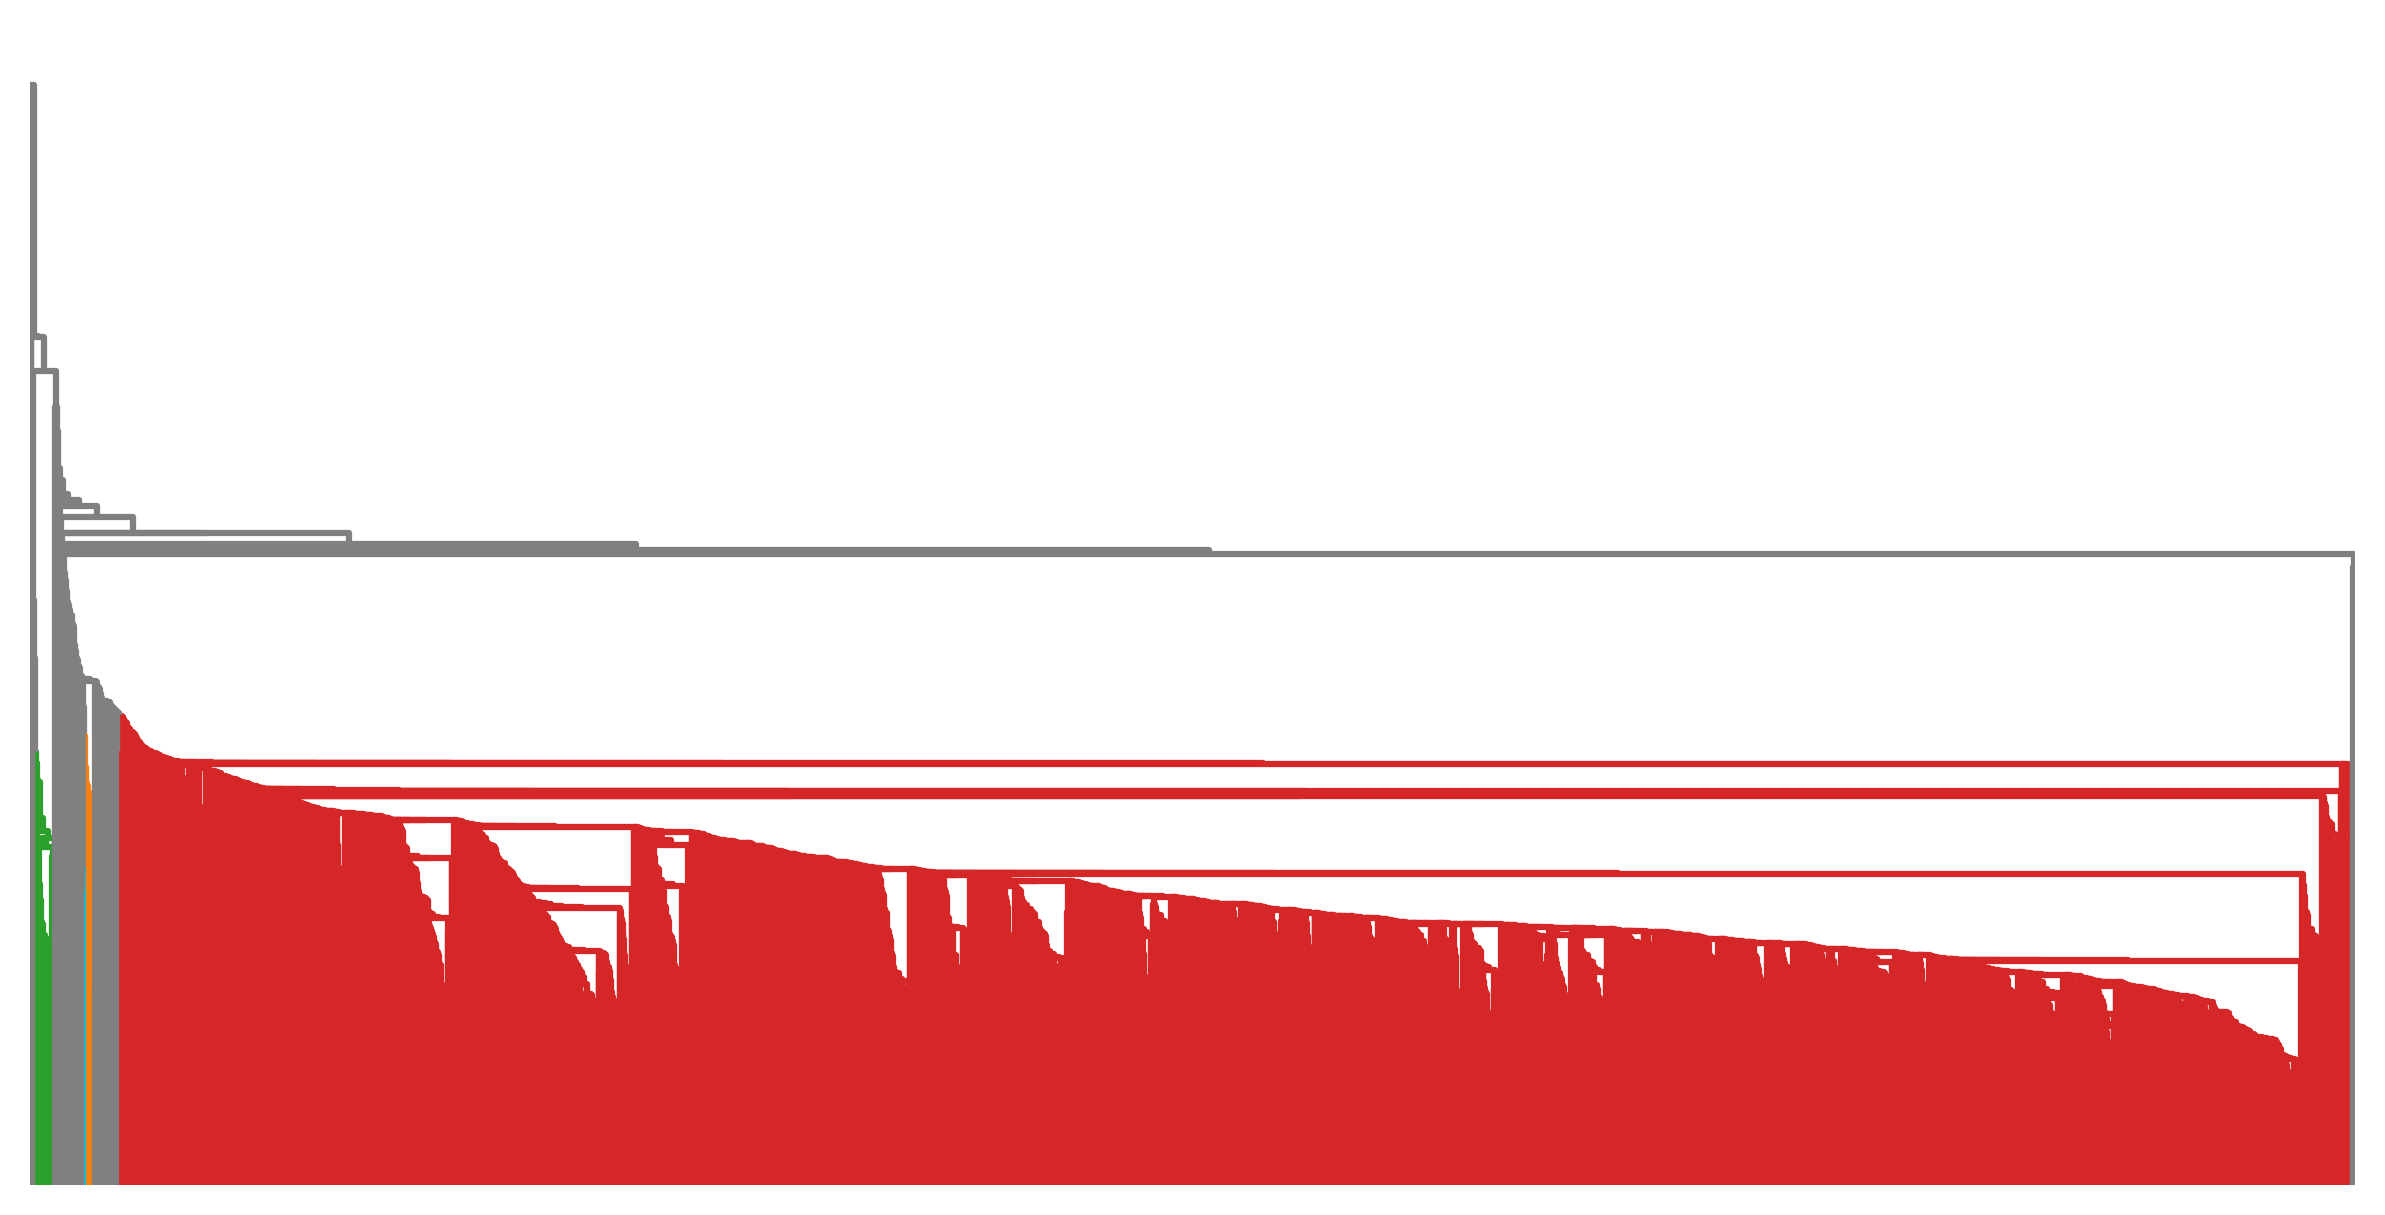

In [29]:
# Plots dendogram of the clustering result

plt.figure(figsize=(10, 5))  # Set the figure size for better visibility
dn = dendrogram(
    heirarchical_clustering,
    color_threshold= cut,  # Adjust this value as needed
    above_threshold_color='gray'  # Color for merges above the threshold
)

axs = plt.gca()
axs.spines['top'].set_visible(False)
axs.spines['right'].set_visible(False)
axs.spines['left'].set_visible(False)
axs.spines['bottom'].set_visible(False)

plt.xticks([])
plt.yticks([])

# plt.savefig("../figures/clustering_dendogram_PADI.pdf", format='pdf', bbox_inches='tight')

In [31]:
tile_data

,Unnamed: 0,aa_seq,abundance,activity,kcluster,heirarchical
0,0,NYVQALFDFDPQEDGELGFRRGDFIHVMDNSDPNWWKGACHGQTGM...,0.005356,0.028944,1,42
1,1,KYVQALFDFEPQEDGELGFRRGDFIHVMDNSDPNWWKGACHGQTGM...,0.093083,-0.114049,1,42
2,2,KYVQALFDFDPQEDGELGFRRGDFIHAMDNSDPNWWKGACHGQTGM...,-1.048527,-0.604463,1,42
3,3,KYVQALFDFDPQEDGELGFRRGDFIHVKDNSDPNWWKGACHGQTGM...,-0.119053,-0.015866,3,42
4,4,KYVQALFDFDPQEDGELGFRRGDFIHVMDNSDPN*WKGACHGQTGM...,-0.542546,-0.734009,2,42
...,...,...,...,...,...,...
5710,5710,MYVQALFDFDPQEDGELGFRRGDVIHVMDNSDPNWWKGACHGQTGM...,0.129528,0.084728,3,42
5711,5711,MYVQALFDFDPQEDGELGFRRGDFIHVMDNSDPNWWKGACHGQTGM...,-1.154684,-0.419314,1,42
5712,5712,MYVQALFDFDPQEDGELGFRRGDFIHVMDNSDPNWWKGACHGQTGM...,0.037401,0.039077,1,42
5713,5713,MYVQALFDFDPQEDGELGFRRGDFIHVMDNSDANWWKGACHGQTGM...,-0.103582,-0.168129,3,42


In [30]:
tile_data["kcluster"] = kcluster_result
tile_data["heirarchical"] = heirarchical_result
tile_data["heirarchical"].value_counts()
# Cluster 15 is train
# Cluster 1-7 is test
# Cluster 9-14 is validation

heirarchical
42    5494
2       56
31      28
36      11
32       6
      ... 
80       1
76       1
45       1
59       1
66       1
Name: count, Length: 100, dtype: int64

In [71]:
unique_padi["kcluster"] = kcluster_result
unique_padi["heirarchical"] = heirarchical_result
unique_padi["heirarchical"].value_counts()
# Cluster 15 is train
# Cluster 1-7 is test
# Cluster 8-14 is validation

unique_padi["cluster"] = [0 if c == 27 else 2 if c <= 14 else 1 for c in unique_padi["heirarchical"]] 
unique_padi["cluster"].value_counts()

cluster
0    1480
2     253
1     184
Name: count, dtype: int64

In [72]:
# Saving cluster results to csv
unique_padi.to_csv("Unique_PADI_Seqs_three_clusters.csv")

In [73]:
training_set = unique_padi[unique_padi["cluster"] == 0]
validation_set = unique_padi[unique_padi["cluster"] == 1]
test_set = unique_padi[unique_padi["cluster"] == 2]

In [74]:
train_tiles = tile_data[[i in set(training_set["Name"]) for i in tile_data["Gene Model"]]]
train_tiles

,Sub Library,Fragment Name,Fragment Sequence,Gene Model,ATG Number,Start Position,PADI Score,TF Family,Mean Disorder,AD Subtype,...,CountV,CountW,CountY,Aromatics,ADScore_mcherry,Lib_mcherry,ScaleScore_mcherry,ADScore_gfp,Lib_GFP,ScaleScore_GFP
40,Lib1,AT1G01030.1_1,MDLSLAPTTTTSSDQEQDRDQELTSNIGASSSSGPSGNNN,AT1G01030.1,AT1G01030,1,-0.951676,B3,0.931392,NaN,...,0,0,0,3,115.214899,mCherry,1.593324,2.529282,GFP,-0.317538
41,Lib1,AT1G01030.1_11,TSSDQEQDRDQELTSNIGASSSSGPSGNNNNLPMMMIPPP,AT1G01030.1,AT1G01030,11,-0.952762,B3,0.885145,NaN,...,0,0,0,2,103.553068,mCherry,1.115635,2.445941,GFP,-0.413132
42,Lib1,AT1G01030.1_21,QELTSNIGASSSSGPSGNNNNLPMMMIPPPEKEHMFDKVV,AT1G01030.1,AT1G01030,21,-0.393286,B3,0.794867,NaN,...,2,0,0,3,84.390123,mCherry,0.330688,2.077748,GFP,-0.835463
43,Lib1,AT1G01030.1_31,SSSGPSGNNNNLPMMMIPPPEKEHMFDKVVTPSDVGKLNR,AT1G01030.1,AT1G01030,31,-0.435035,B3,0.672268,NaN,...,3,0,0,3,75.162442,mCherry,-0.047293,2.668595,GFP,-0.157740
44,Lib1,AT1G01030.1_41,NLPMMMIPPPEKEHMFDKVVTPSDVGKLNRLVIPKQHAER,AT1G01030.1,AT1G01030,41,-0.029284,B3,0.533780,NaN,...,4,0,0,4,94.794698,mCherry,0.756878,1.709077,GFP,-1.258341
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69554,Lib10,AT5G67580.1_221,ANSLTKFRVDGELYMIKGMTAQEAAEAAARAVAEAEFAIT,AT5G67580.1,AT5G67580,221,-0.506341,MYB_related,0.137923,NaN,...,2,0,1,5,93.184692,mCherry,0.690929,2.309094,GFP,-0.570101
69555,Lib10,AT5G67580.1_231,GELYMIKGMTAQEAAEAAARAVAEAEFAITEAEQAAKEAE,AT5G67580.1,AT5G67580,231,-0.548984,MYB_related,0.061055,NaN,...,1,0,1,3,92.894340,mCherry,0.679036,2.451830,GFP,-0.406378
69556,Lib10,AT5G67580.1_241,AQEAAEAAARAVAEAEFAITEAEQAAKEAERAEAEAEAAQ,AT5G67580.1,AT5G67580,241,-0.477315,MYB_related,0.067760,NaN,...,1,0,0,1,76.339098,mCherry,0.000905,2.277062,GFP,-0.606843
69557,Lib10,AT5G67580.1_251,AVAEAEFAITEAEQAAKEAERAEAEAEAAQIFAKAAMKAL,AT5G67580.1,AT5G67580,251,-0.342461,MYB_related,0.054605,NaN,...,1,0,0,3,70.528067,mCherry,-0.237125,2.335950,GFP,-0.539296


In [75]:
val_tiles = tile_data[[i in set(validation_set["Name"]) for i in tile_data["Gene Model"]]]
val_tiles

,Sub Library,Fragment Name,Fragment Sequence,Gene Model,ATG Number,Start Position,PADI Score,TF Family,Mean Disorder,AD Subtype,...,CountV,CountW,CountY,Aromatics,ADScore_mcherry,Lib_mcherry,ScaleScore_mcherry,ADScore_gfp,Lib_GFP,ScaleScore_GFP
498,Lib1,AT1G02210.1_1,MVWFFFSCDEYNEEILKTNSGYWKETVSNTPIIGKWITSN,AT1G02210.1,AT1G02210,1,-0.100962,NAC,0.189975,NaN,...,2,3,2,9,73.697009,mCherry,-0.107320,2.516184,GFP,-0.332561
499,Lib1,AT1G02210.1_11,YNEEILKTNSGYWKETVSNTPIIGKWITSNGVKIGEKQVL,AT1G02210.1,AT1G02210,11,-0.552659,NAC,0.097577,NaN,...,3,2,2,6,NaN,mCherry,NaN,2.255813,GFP,-0.631216
500,Lib1,AT1G02210.1_21,GYWKETVSNTPIIGKWITSNGVKIGEKQVLVFQSYENING,AT1G02210.1,AT1G02210,21,-0.327748,NAC,0.077630,NaN,...,4,2,2,6,69.589572,mCherry,-0.275567,2.461272,GFP,-0.395547
501,Lib1,AT1G02210.1_31,PIIGKWITSNGVKIGEKQVLVFQSYENINGSKSDWVMHVY,AT1G02210.1,AT1G02210,31,-0.666769,NAC,0.066293,NaN,...,5,2,2,6,40.415164,mCherry,-1.470601,1.720807,GFP,-1.244887
502,Lib1,AT1G02210.1_41,GVKIGEKQVLVFQSYENINGSKSDWVMHVYQPTFLPPNQV,AT1G02210.1,AT1G02210,41,-0.062070,NAC,0.085335,NaN,...,6,1,2,7,51.245793,mCherry,-1.026960,2.188221,GFP,-0.708747
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69568,Lib10,ATMG00940.1_91,SDFVVKAEDVEASMAIFWTPGTRVKMAMETEDSSRITWFQ,ATMG00940.1,ATMG00940,91,-0.139281,Other,0.084480,NaN,...,4,2,0,5,82.104793,mCherry,0.237077,2.778634,GFP,-0.031522
69569,Lib10,ATMG00940.1_101,EASMAIFWTPGTRVKMAMETEDSSRITWFQGIVFYTYQET,ATMG00940.1,ATMG00940,101,-0.064551,Other,0.104625,NaN,...,2,2,2,7,52.669874,mCherry,-0.968627,2.185097,GFP,-0.712330
69570,Lib10,ATMG00940.1_111,GTRVKMAMETEDSSRITWFQGIVFYTYQETGPWRGSPWNS,ATMG00940.1,ATMG00940,111,-0.410777,Other,0.159452,NaN,...,2,3,2,7,86.482637,mCherry,0.416401,1.951123,GFP,-0.980707
69571,Lib10,ATMG00940.1_121,EDSSRITWFQGIVFYTYQETGPWRGSPWNSFRYKIPFTIP,ATMG00940.1,ATMG00940,121,0.329820,Other,0.204375,NaN,...,1,3,3,10,103.355376,mCherry,1.107537,3.239086,GFP,0.496633


In [76]:
test_tiles = tile_data[[i in set(test_set["Name"]) for i in tile_data["Gene Model"]]]
test_tiles

,Sub Library,Fragment Name,Fragment Sequence,Gene Model,ATG Number,Start Position,PADI Score,TF Family,Mean Disorder,AD Subtype,...,CountV,CountW,CountY,Aromatics,ADScore_mcherry,Lib_mcherry,ScaleScore_mcherry,ADScore_gfp,Lib_GFP,ScaleScore_GFP
0,Lib1,AT1G01010.1_1,MEDQVGFGFRPNDEELVGHYLRNKIEGNTSRDVEVAISEV,AT1G01010.1,AT1G01010,1,1.004699,NAC,0.254442,1.0,...,5,0,1,5,NaN,mCherry,NaN,NaN,GFP,NaN
1,Lib1,AT1G01010.1_11,PNDEELVGHYLRNKIEGNTSRDVEVAISEVNICSYDPWNL,AT1G01010.1,AT1G01010,11,0.575876,NAC,0.131235,NaN,...,4,1,2,6,116.821370,mCherry,1.659127,NaN,GFP,NaN
2,Lib1,AT1G01010.1_21,LRNKIEGNTSRDVEVAISEVNICSYDPWNLRFQSKYKSRD,AT1G01010.1,AT1G01010,21,-0.300407,NAC,0.104265,NaN,...,3,1,2,6,119.407486,mCherry,1.765059,2.139619,GFP,-0.764495
3,Lib1,AT1G01010.1_31,RDVEVAISEVNICSYDPWNLRFQSKYKSRDAMWYFFSRRE,AT1G01010.1,AT1G01010,31,0.105372,NAC,0.105342,NaN,...,3,2,3,9,57.726857,mCherry,-0.761484,2.009344,GFP,-0.913925
4,Lib1,AT1G01010.1_41,NICSYDPWNLRFQSKYKSRDAMWYFFSRRENNKGNRQSRT,AT1G01010.1,AT1G01010,41,-0.167147,NAC,0.240860,NaN,...,0,2,3,9,68.588378,mCherry,-0.316578,2.250430,GFP,-0.637390
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69429,Lib10,AT5G67300.1_231,SFMPFSGGFRGAIEEMGKSFPGNGGEFMAVVQEMIKAEVR,AT5G67300.1,AT5G67300,231,-0.172001,MYB,0.445872,NaN,...,3,0,0,5,53.204673,mCherry,-0.946721,2.718643,GFP,-0.100334
69430,Lib10,AT5G67300.1_241,GAIEEMGKSFPGNGGEFMAVVQEMIKAEVRSYMTEMQRNN,AT5G67300.1,AT5G67300,241,-0.251551,MYB,0.310802,NaN,...,3,0,1,3,51.190983,mCherry,-1.029205,NaN,GFP,NaN
69431,Lib10,AT5G67300.1_251,PGNGGEFMAVVQEMIKAEVRSYMTEMQRNNGGGFVGGFID,AT5G67300.1,AT5G67300,251,-0.364791,MYB,0.336458,NaN,...,4,0,1,4,78.315585,mCherry,0.081865,2.616433,GFP,-0.217572
69432,Lib10,AT5G67300.1_261,VQEMIKAEVRSYMTEMQRNNGGGFVGGFIDNGMIPMSQIG,AT5G67300.1,AT5G67300,261,-0.155113,MYB,0.426587,NaN,...,3,0,1,3,66.048624,mCherry,-0.420611,2.445543,GFP,-0.413589


In [79]:
other_tiles = tile_data[[(i not in set(validation_set["Name"])) and (i not in set(training_set["Name"])) and (i not in set(test_set["Name"])) for i in tile_data["Gene Model"]]]
other_tiles

,Sub Library,Fragment Name,Fragment Sequence,Gene Model,ATG Number,Start Position,PADI Score,TF Family,Mean Disorder,AD Subtype,...,CountV,CountW,CountY,Aromatics,ADScore_mcherry,Lib_mcherry,ScaleScore_mcherry,ADScore_gfp,Lib_GFP,ScaleScore_GFP


In [82]:
# Loading in the tiles that we actually have experimental results for
experiment_data = pd.read_csv("PADI_ADScore_data_wrangled.csv", index_col=0)
experiment_data

,aa_seq,abundance,activity
2,LRNKIEGNTSRDVEVAISEVNICSYDPWNLRFQSKYKSRD,119.407486,2.139619
3,RDVEVAISEVNICSYDPWNLRFQSKYKSRDAMWYFFSRRE,57.726857,2.009344
4,NICSYDPWNLRFQSKYKSRDAMWYFFSRRENNKGNRQSRT,68.588378,2.250430
5,RFQSKYKSRDAMWYFFSRRENNKGNRQSRTTVSGKWKLTG,71.863085,2.641251
6,AMWYFFSRRENNKGNRQSRTTVSGKWKLTGESVEVKDQWG,71.389912,3.081572
...,...,...,...
69568,SDFVVKAEDVEASMAIFWTPGTRVKMAMETEDSSRITWFQ,82.104793,2.778634
69569,EASMAIFWTPGTRVKMAMETEDSSRITWFQGIVFYTYQET,52.669874,2.185097
69570,GTRVKMAMETEDSSRITWFQGIVFYTYQETGPWRGSPWNS,86.482637,1.951123
69571,EDSSRITWFQGIVFYTYQETGPWRGSPWNSFRYKIPFTIP,103.355376,3.239086


In [87]:
train_seqs_set = set(train_tiles["Fragment Sequence"])
training_data = experiment_data[[i in train_seqs_set for i in experiment_data["aa_seq"]]]
training_data

,aa_seq,abundance,activity
40,MDLSLAPTTTTSSDQEQDRDQELTSNIGASSSSGPSGNNN,115.214899,2.529282
41,TSSDQEQDRDQELTSNIGASSSSGPSGNNNNLPMMMIPPP,103.553068,2.445941
42,QELTSNIGASSSSGPSGNNNNLPMMMIPPPEKEHMFDKVV,84.390123,2.077748
43,SSSGPSGNNNNLPMMMIPPPEKEHMFDKVVTPSDVGKLNR,75.162442,2.668595
44,NLPMMMIPPPEKEHMFDKVVTPSDVGKLNRLVIPKQHAER,94.794698,1.709077
...,...,...,...
69554,ANSLTKFRVDGELYMIKGMTAQEAAEAAARAVAEAEFAIT,93.184692,2.309094
69555,GELYMIKGMTAQEAAEAAARAVAEAEFAITEAEQAAKEAE,92.894340,2.451830
69556,AQEAAEAAARAVAEAEFAITEAEQAAKEAERAEAEAEAAQ,76.339098,2.277062
69557,AVAEAEFAITEAEQAAKEAERAEAEAEAAQIFAKAAMKAL,70.528067,2.335950


In [89]:
val_seqs_set = set(val_tiles["Fragment Sequence"])
validation_data = experiment_data[[((i in val_seqs_set)) for i in experiment_data["aa_seq"]]]
validation_data

,aa_seq,abundance,activity
498,MVWFFFSCDEYNEEILKTNSGYWKETVSNTPIIGKWITSN,73.697009,2.516184
500,GYWKETVSNTPIIGKWITSNGVKIGEKQVLVFQSYENING,69.589572,2.461272
501,PIIGKWITSNGVKIGEKQVLVFQSYENINGSKSDWVMHVY,40.415164,1.720807
502,GVKIGEKQVLVFQSYENINGSKSDWVMHVYQPTFLPPNQV,51.245793,2.188221
503,QVLVFQSYENINGSKSDWVMHVYQPTFLPPNQVIFRIYDV,61.224384,2.383230
...,...,...,...
69568,SDFVVKAEDVEASMAIFWTPGTRVKMAMETEDSSRITWFQ,82.104793,2.778634
69569,EASMAIFWTPGTRVKMAMETEDSSRITWFQGIVFYTYQET,52.669874,2.185097
69570,GTRVKMAMETEDSSRITWFQGIVFYTYQETGPWRGSPWNS,86.482637,1.951123
69571,EDSSRITWFQGIVFYTYQETGPWRGSPWNSFRYKIPFTIP,103.355376,3.239086


In [91]:
test_seqs_set = set(test_tiles["Fragment Sequence"])
other_seqs_set = set(other_tiles["Fragment Sequence"])
test_data = experiment_data[[((i in test_seqs_set ) or (i in other_seqs_set)) for i in experiment_data["aa_seq"]]]
test_data

,aa_seq,abundance,activity
2,LRNKIEGNTSRDVEVAISEVNICSYDPWNLRFQSKYKSRD,119.407486,2.139619
3,RDVEVAISEVNICSYDPWNLRFQSKYKSRDAMWYFFSRRE,57.726857,2.009344
4,NICSYDPWNLRFQSKYKSRDAMWYFFSRRENNKGNRQSRT,68.588378,2.250430
5,RFQSKYKSRDAMWYFFSRRENNKGNRQSRTTVSGKWKLTG,71.863085,2.641251
6,AMWYFFSRRENNKGNRQSRTTVSGKWKLTGESVEVKDQWG,71.389912,3.081572
...,...,...,...
69428,SSRHNHNNTVSFMPFSGGFRGAIEEMGKSFPGNGGEFMAV,56.887135,2.596344
69429,SFMPFSGGFRGAIEEMGKSFPGNGGEFMAVVQEMIKAEVR,53.204673,2.718643
69431,PGNGGEFMAVVQEMIKAEVRSYMTEMQRNNGGGFVGGFID,78.315585,2.616433
69432,VQEMIKAEVRSYMTEMQRNNGGGFVGGFIDNGMIPMSQIG,66.048624,2.445543


In [92]:
# These are the data files used in trainning
validation_data.to_csv("PADI_data_wrangled_validation_heirarchical.csv",index=False)
training_data.to_csv("PADI_data_wrangled_training_heirarchical.csv",index=False)
test_data.to_csv("PADI_data_wrangled_test_heirarchical.csv",index=False)

# Testing tile overlap

In [26]:
# This file was created on savio (find where) and counts the overlap between all tiles
# Is very large so takes a bit to load
overlap_matrix = pd.read_csv("all_seqs_overlap_matrix.csv")

/var/folders/34/1pw3__x51kdfyh3vk72f5vc80000gn/T/ipykernel_58991/1187536956.py:3: DtypeWarning: Columns (1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251

In [27]:
overlap_matrix.index = overlap_matrix["Sequence"]
overlap_matrix = overlap_matrix.drop("Sequence", axis=1)

In [28]:
# filtering the matrix to be validation x training
overlap_train_test = overlap_matrix.loc[test_data["aa_seq"].values, training_data["aa_seq"].values]
overlap_train_test

,LQDFVLFDQPIRPHRQHNRNALQPPTRGINLNQQHRSQHL,VEHSPAEKSDDLEVVEPTSGHQRRKSGTSPPSGRHSSVSG,NAGTASRFLTTVVALCSPSDVSSTVLTGNARMQVRPIGPL,SSTTALQQQHRQTRPQVPLFSQSTGSIPKTPNMVMQGTYI,KGGKLQASKEALYLGNAGTASRFLTTVVALCSPSDVSSTV,LHNITMDHGKERNDCRPDEANGSHSGSCLPISSTPREQWR,IAGATSKEPMLSLNEDNENNDDDADDADDDDDALVPREDT,AKVEQSPLLPEEEFEVSEHLRNSTGRRRSGTGTSPSGTHA,THASIAGVNSRKRDKPLPPIIVDDPNDTVAMKRARNTLAA,ISLPLERTISSQSMERSGSSSSGSPVVLDGSSFRRKSSVT,...,DAVVESFFSSSTDSTPMFEYENLEDNSKEWTSLFDNDIPV,FDGSPDFDTFDISPSFGHSDLDNPDSWFSLFPDANPLPQA,DLDSAVENFFGSSSDSTPLFEFEGLGKTADPKTWSSLFDD,SAVVDTFFSSSTDSSPMFEFENLESDPKSWGSLFDNDIPV,DIGESPYLDNYDQSPGIFAGDAVMASDNWFSLFPEDDIKV,PTPTFSSPYLFDSPSEGYETSPLFGAEDTNGDNWYSLFPE,DAWFSLFPSISGGENDESPLSAAEDVMVADPFNISAQVVL,LYDESPDFGSGFDVSPNFAGSDFDAGGNDVWFPLFPQSNT,LYESPDFGYDVSPGFGSNDFDTGSNQWFSLFPDQSTTPDA,IEESMDECIRWLENPFLNQFIAGFDLIGEEATEKHPLIYH
Sequence,,,,,,,,,,,,,,,,,,,,,
GPLFPAQDDFSTAFDSAALDAAIALSQPETIPAKEISVPP,2,2,3,3,2,2,2,2,2,2,...,2,3,3,2,3,3,3,4,3,2
TNVIAQAQGYRPSSHRLSLPGPARLSQRQHIYAASDPSNS,3,2,2,2,2,2,3,2,2,3,...,2,2,2,3,3,2,2,2,2,2
PPTDVSAGDEAHADGEDVAMAHADAADDFDADMAGDGDSP,3,2,3,1,3,3,3,2,3,2,...,2,3,2,2,3,3,3,4,3,2
SAFDSAALDVALALSQPETKPAKEVSVPPSPAIRNSASPA,2,3,3,2,3,2,2,3,2,2,...,2,2,3,2,2,3,3,2,2,2
SSTNLDDLSAAVSAPPKTVPPPPSPMVRAASSPGQSTGTS,2,3,3,4,3,3,2,4,2,2,...,3,2,3,3,3,3,4,2,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PGYFSQDTSPMFATDMELGPGVEEWGSLFPSQDDFSLGLD,2,3,2,3,2,2,2,3,2,2,...,3,4,3,5,4,4,5,3,4,2
YFSQDTSPMFPTDLELNPGHEEWDSLFPPQDGFPVAFDSA,2,3,2,3,2,1,2,3,2,2,...,3,4,3,4,4,4,4,3,4,2
PDTLRLDLRTNFDDPEFFDFTEGFGEEFTDSTMLSPHLVP,2,2,2,2,2,2,3,3,3,2,...,4,2,3,3,2,2,2,2,3,3


In [29]:
# For each sequence in validation set, calcualte max overlap with train set
max_train_val_overlap = pd.DataFrame(overlap_train_test.max(axis=1)).reset_index()

In [30]:
model = "../model_data/two_state_abundmodel_b10_e200_L0.001_sMinMax_aHill_c1_k40_ak5_ParaReLU_0.1PosKLoss_0.5PosWeightLoss_hSplit_hv1_seed1298091_weightInit_v2"

In [31]:
import torch

# Biophysical model parameters
size = (1,40,20)
hill_value = 1
relu = False
outchannel = 1

# Loading the "best" model, as defined above based on val data
# We also are filtering to use Hill value as that gave systematically better pearson correlations
kernel_size_two = 40
abund_k_two = 5
activity_fun = "Hill"

two_state_biophysical_model = ADModel_two_state_abund(size,activity_fun, kernel_size_two, relu=False, abund_k=abund_k_two)
two_state_biophysical_model.load_state_dict(torch.load(f"{model}.pth"))

two_state_biophysical_model.eval()

# Loading the scaler
sc_act = load("../Model/scaler_activity.bin")
sc_abund = load("../Model/scaler_activity.bin")


def run_biophysical_model(loaded_model,sequence):
    """
    Takes a sequence and run the model on sequence
    """
    encoded_seq = one_hot_encode(sequence).reshape(1,1,40,20)
    seq_tensor = torch.from_numpy(encoded_seq).type(torch.FloatTensor)
    predictions = loaded_model(seq_tensor)
    predictions_act = sc_act.inverse_transform(predictions.detach().numpy().reshape(-1)[1].reshape(1,-1))
    predictions_abund = sc_abund.inverse_transform(predictions.detach().numpy().reshape(-1)[0].reshape(1,-1))
    return predictions_abund, predictions_act


/Users/claireleblanc/miniconda3/envs/predictors_simple/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.4.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [32]:
# Run the best model on the test data
test_data["abund_pred"] = [run_biophysical_model(two_state_biophysical_model, seq)[0][0][0] for seq in test_data['aa_seq']]
test_data["activity_pred"] = [run_biophysical_model(two_state_biophysical_model, seq)[1][0][0] for seq in test_data['aa_seq']]

/var/folders/34/1pw3__x51kdfyh3vk72f5vc80000gn/T/ipykernel_58991/829659965.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data["abund_pred"] = [run_biophysical_model(two_state_biophysical_model, seq)[0][0][0] for seq in test_data['aa_seq']]
/var/folders/34/1pw3__x51kdfyh3vk72f5vc80000gn/T/ipykernel_58991/829659965.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data["activity_pred"] = [run_biophysical_model(two_state_biophysical_model, seq)[1][0][0] for seq in test_data['aa_seq']]


In [43]:
# For each prediction, calculate how wrong it was
test_data["abund_diff"] = abs(test_data["abundance"] - test_data["abund_pred"])

test_data["act_diff"] = abs(test_data["activity"] - test_data["activity_pred"])

/var/folders/34/1pw3__x51kdfyh3vk72f5vc80000gn/T/ipykernel_58991/1039998952.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data["abund_diff"] = abs(test_data["abundance"] - test_data["abund_pred"])
/var/folders/34/1pw3__x51kdfyh3vk72f5vc80000gn/T/ipykernel_58991/1039998952.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data["act_diff"] = abs(test_data["activity"] - test_data["activity_pred"])


In [44]:
# Merge so that we also know how much each test sequence overlaps with train
merged = max_train_val_overlap.merge(test_data, left_on='Sequence', right_on="aa_seq")

In [45]:
# Making the overlap column (0) a number to display better
merged[0] = pd.to_numeric(merged[0])
merged.sort_values(by=0)

,Sequence,0,aa_seq,activity,abundance,ratio,abund_pred,activity_pred,abund_diff,act_diff
1567,TDFIDEEVIMSIVIEMGIDRIKEIPEIWIGQNEFDFMTDF,4,TDFIDEEVIMSIVIEMGIDRIKEIPEIWIGQNEFDFMTDF,2591.749551,466.644461,160550.822518,2890.750244,4471.351562,2424.105783,1879.602011
1360,KTARRERRGHVHCVGGGAGGPWCPMFGRGCPLLWQNASYQ,4,KTARRERRGHVHCVGGGAGGPWCPMFGRGCPLLWQNASYQ,2081.429863,2945.085591,40385.191942,731.854858,360.951202,2213.230733,1720.478660
573,ALFDFGNTSDDITLGVKPTMLSPKQLQTNSNMSDDTFAGL,4,ALFDFGNTSDDITLGVKPTMLSPKQLQTNSNMSDDTFAGL,2843.671146,2299.850586,54572.195452,4962.313965,3817.421143,2662.463378,973.749997
1356,YAVWVRCEDGGNQLHEFHASPIRVSPLYALATWEPPVPGP,4,YAVWVRCEDGGNQLHEFHASPIRVSPLYALATWEPPVPGP,1483.175519,1265.057604,64470.756364,2407.476562,1387.429810,1142.418958,95.745709
287,VLIHVRSTAGDYEVHLPVSNHRVPAAFHGFVESDGHVSDR,4,VLIHVRSTAGDYEVHLPVSNHRVPAAFHGFVESDGHVSDR,922.624451,1799.234219,31721.237102,4377.397461,285.960327,2578.163242,636.664123
...,...,...,...,...,...,...,...,...,...,...
953,DDAVVESFFSSSTDSTPMFEYENLEDNSKEATSAADNDIP,30,DDAVVESFFSSSTDSTPMFEYENLEDNSKEATSAADNDIP,2497.961303,3395.591372,31649.629665,6818.488281,3156.334717,3422.896909,658.373414
1958,DDAVVESAASSSTDSTPMFEYENLEDNSKEWTSLFDNDIP,31,DDAVVESAASSSTDSTPMFEYENLEDNSKEWTSLFDNDIP,3068.542196,3465.680199,122630.655898,5518.635254,4495.419922,2052.955055,1426.877726
1475,DDAVVESFFSSSTDSTPMFEYENLEDNSKEWTSLFDNDIP,39,DDAVVESFFSSSTDSTPMFEYENLEDNSKEWTSLFDNDIP,8606.649309,3081.663333,259498.893322,5320.946777,6574.916504,2239.283444,2031.732805
1695,LTALTSPSLFDGSPDFDTFDISPNFGHSDLENPDTWFSLF,40,LTALTSPSLFDGSPDFDTFDISPNFGHSDLENPDTWFSLF,8894.798491,2780.916344,260471.624978,3839.638672,8201.679688,1058.722328,693.118803


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


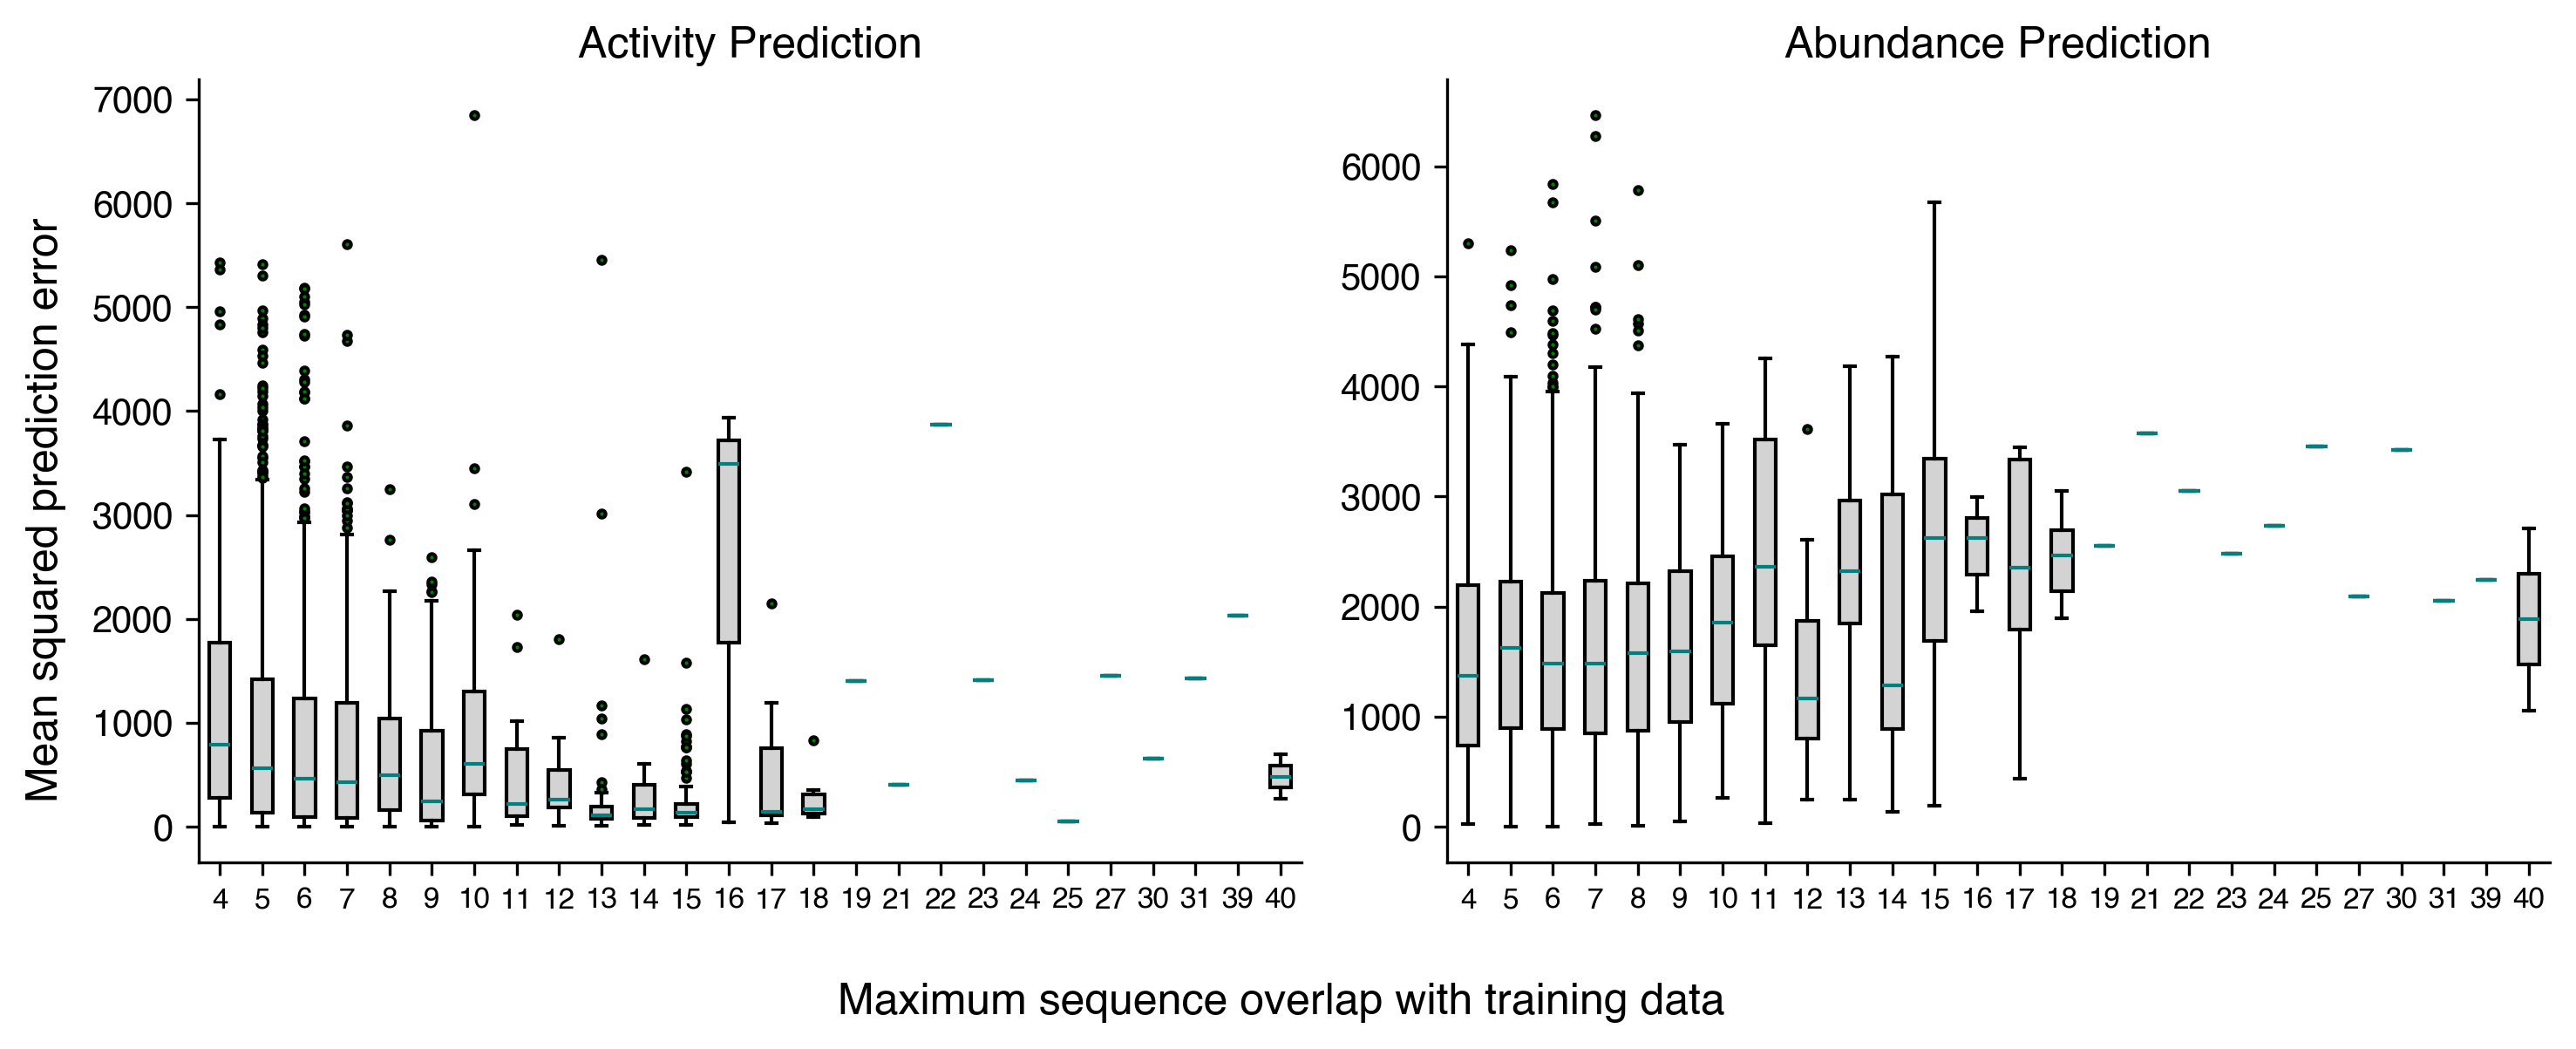

In [46]:
# Group by overlap
grouped = merged.sort_values(by=0).groupby(0)

# Prepare the boxplot for act_diff within each group
fig, ax = plt.subplots(1, 2, figsize=(10,4))

# Collect data for each group
data_to_plot = [group['act_diff'] for name, group in grouped]

flierprops = dict(marker='o', markerfacecolor='green', markersize=2, linestyle='none', markeredgecolor='black')

# Create first boxplot, for activity
bp = ax[0].boxplot(data_to_plot, patch_artist=True, flierprops=flierprops)

# Customizing whiskers, caps, and medians
for whisker in bp['whiskers']:
    whisker.set(color='black')
    
for patch in bp['boxes']:
    patch.set_facecolor('lightgrey')

for cap in bp['caps']:
    cap.set(color='black')

for median in bp['medians']:
    median.set(color='teal')


# Create second boxplot, for abundance
grouped = merged.sort_values(by=0).groupby(0)

data_to_plot = [group['abund_diff'] for name, group in grouped]
bp = ax[1].boxplot(data_to_plot, patch_artist=True, flierprops=flierprops)

# Customizing whiskers, caps, and medians
for whisker in bp['whiskers']:
    whisker.set(color='black')
    
for patch in bp['boxes']:
    patch.set_facecolor('lightgrey')

for cap in bp['caps']:
    cap.set(color='black')

for median in bp['medians']:
    median.set(color='teal')


font_properties = {'size': 8}
# Setting x-tick labels with group names
ax[0].set_xticklabels([name for name, _ in grouped], fontdict=font_properties)
ax[1].set_xticklabels([name for name, _ in grouped], fontdict=font_properties)

# Adding labels and title
fig.supxlabel('Maximum sequence overlap with training data')
fig.supylabel('Mean squared prediction error')

ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)

ax[0].set_title("Activity Prediction")
ax[1].set_title("Abundance Prediction")

fig.tight_layout()
plt.savefig("../figures/train_test_overlap.pdf", format='pdf', bbox_inches='tight')


In [53]:
spearmanr(merged[0], merged["abund_diff"])

SignificanceResult(statistic=0.13752260174536063, pvalue=3.998095665963089e-12)

In [54]:
spearmanr(merged[0], merged["act_diff"])

SignificanceResult(statistic=-0.15394990288384638, pvalue=7.521834832317861e-15)